In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
# Aplicar configuraciones de visualización total de Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

In [2]:
df_forecast = pd.read_excel("revisar2.xlsx")

In [3]:
df_calendar = pd.read_excel("CalendarFinal.xlsx")

In [4]:
# Solución óptima y vectorizada
df_calendar["ds"] = pd.to_datetime(df_calendar["fecha"])
df_calendar.drop(columns=["fecha"], inplace=True)

In [5]:
df_calendar.head()

,black_friday,dia_de_la_madre,dia_del_padre,efecto_fin_mes,efecto_quincena,fiestas_patrias,halloween,navidad,nuevo_año,post_año_nuevo,post_navidad,pre_navidad,pre_nuevo_año,san_valentin,semana_santa,ds
0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,2024-01-01
1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2024-01-15
2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,2024-01-31
3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2024-02-13
4,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2024-02-14


In [6]:
df_forecast1 = df_forecast.merge(df_calendar, on="ds", how="left")

In [7]:
df_forecast1 = df_forecast1.fillna(0)

In [8]:
df_forecast1.columns

Index(['ds', 'trend', 'weekly', 'yearly', 'yhat', 'y', 'black_friday',
       'dia_de_la_madre', 'dia_del_padre', 'efecto_fin_mes', 'efecto_quincena',
       'fiestas_patrias', 'halloween', 'navidad', 'nuevo_año',
       'post_año_nuevo', 'post_navidad', 'pre_navidad', 'pre_nuevo_año',
       'san_valentin', 'semana_santa'],
      dtype='object')

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df_forecast1[['trend', 'weekly', 'yearly', 'black_friday',
       'dia_de_la_madre', 'dia_del_padre', 'efecto_fin_mes', 'efecto_quincena',
       'fiestas_patrias', 'halloween', 'navidad', 'nuevo_año',
       'post_año_nuevo', 'post_navidad', 'pre_navidad', 'pre_nuevo_año',
       'san_valentin', 'semana_santa']]
y = df_forecast1["y"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model = LinearRegression(n_jobs=-1)  # n_jobs=-1 utiliza todos los cores disponibles
model.fit(X_train, y_train)

# Inferencia
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [12]:
df_forecast1.head()

,ds,trend,weekly,yearly,yhat,y,black_friday,dia_de_la_madre,dia_del_padre,efecto_fin_mes,efecto_quincena,fiestas_patrias,halloween,navidad,nuevo_año,post_año_nuevo,post_navidad,pre_navidad,pre_nuevo_año,san_valentin,semana_santa
0,2024-01-01,69093.954728,7044.218541,50.296512,76188.469781,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2024-01-02,69104.545266,-1306.322279,-1419.485735,66378.737252,85116.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-01-03,69115.135804,-7638.160198,-2765.438358,58711.537248,74078.11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-01-04,69125.726342,-8906.742859,-3972.277089,56246.706394,65554.26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-01-05,69136.316880,-6889.340880,-5028.035689,57218.940311,60943.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(df_forecast1["y"], df_forecast1["yhat"])),
    "Test RMSE": np.sqrt(mean_squared_error(df_forecast1["y"], df_forecast1["yhat"])),
    "Train R2": r2_score(df_forecast1["y"], df_forecast1["yhat"]),
    "Test R2": r2_score(df_forecast1["y"], df_forecast1["yhat"])
}

print("--- RENDIMIENTO DEL MODELO ---")
for metric_name, value in metrics.items():
    print(f"{metric_name}: {value:.4f}")

--- RENDIMIENTO DEL MODELO ---
Train RMSE: 8899.1936
Test RMSE: 8899.1936
Train R2: 0.5284
Test R2: 0.5284


In [14]:
metrics = {
    "Train RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
    "Train R2": r2_score(y_train, y_pred_train),
    "Test R2": r2_score(y_test, y_pred_test)
}

print("--- RENDIMIENTO DEL MODELO ---")
for metric_name, value in metrics.items():
    print(f"{metric_name}: {value:.4f}")

print("\n--- COEFICIENTES DEL MODELO ($\hat{\beta}$) ---")
print(f"Intercepto ($\hat{{\beta}}_0$): {model.intercept_:.4f}")
for col, coef in zip(X.columns, model.coef_):
    print(f"{col}: {coef:.4f}")

--- RENDIMIENTO DEL MODELO ---
Train RMSE: 6629.8896
Test RMSE: 7167.1135
Train R2: 0.7257
Test R2: 0.7411

--- COEFICIENTES DEL MODELO ($\hateta}$) ---
Intercepto ($\hateta}_0$): -24248.6254
trend: 1.3466
weekly: 0.9799
yearly: 0.8877
black_friday: -2680.1320
dia_de_la_madre: -3807.2481
dia_del_padre: -1732.6593
efecto_fin_mes: 5251.2312
efecto_quincena: 3366.7513
fiestas_patrias: -14886.1796
halloween: 6084.3316
navidad: 16796.8211
nuevo_año: -3167.1400
post_año_nuevo: -65962.1940
post_navidad: -47031.2904
pre_navidad: 25965.8605
pre_nuevo_año: -5856.6483
san_valentin: 7163.0012
semana_santa: -8672.7120


<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:13: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:13: SyntaxWarning: invalid escape sequence '\h'
C:\Users\eparedes\AppData\Local\Temp\ipykernel_19276\3705200056.py:12: SyntaxWarning: invalid escape sequence '\h'
  print("\n--- COEFICIENTES DEL MODELO ($\hat{\beta}$) ---")
C:\Users\eparedes\AppData\Local\Temp\ipykernel_19276\3705200056.py:13: SyntaxWarning: invalid escape sequence '\h'
  print(f"Intercepto ($\hat{{\beta}}_0$): {model.intercept_:.4f}")


<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:17: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:17: SyntaxWarning: invalid escape sequence '\h'
C:\Users\eparedes\AppData\Local\Temp\ipykernel_19276\1964124509.py:7: SyntaxWarning: invalid escape sequence '\h'
  axes[0].set_title("Valores Reales vs. Predicciones ($\hat{y}$)", fontsize=12, pad=10)
C:\Users\eparedes\AppData\Local\Temp\ipykernel_19276\1964124509.py:9: SyntaxWarning: invalid escape sequence '\h'
  axes[0].set_ylabel("Predicción ($\hat{y}$)", fontsize=10)
C:\Users\eparedes\AppData\Local\Temp\ipykernel_19276\1964124509.py:16: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_xlabel("Predicción ($\hat{y}$)", fontsize=10)
C:\Users\eparedes\AppData\Local\Temp\ipykerne

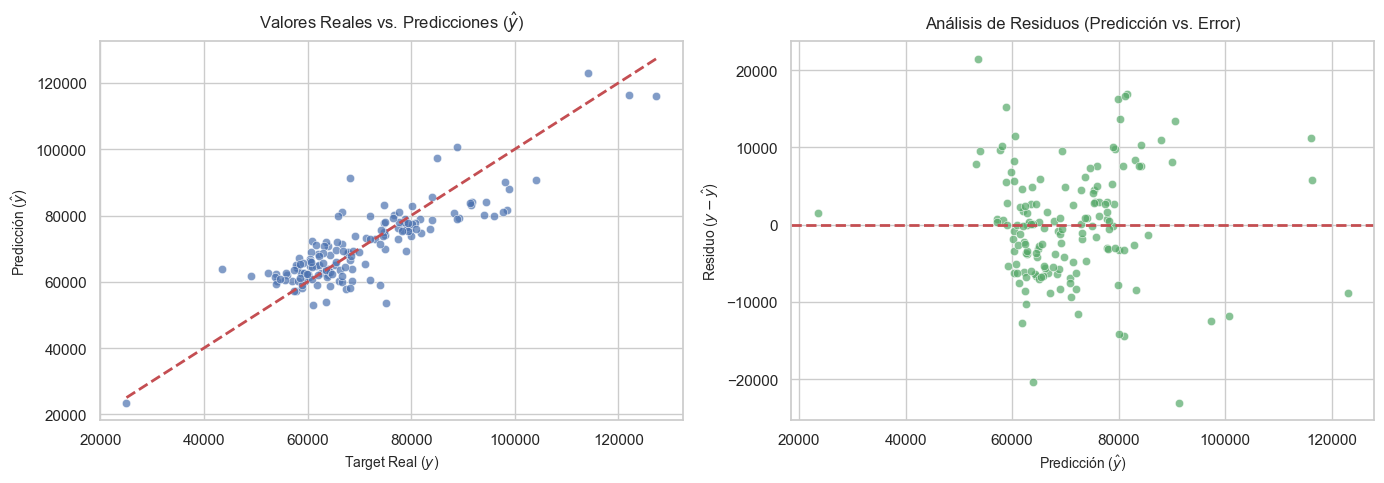

In [15]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Valores Reales vs Predicciones
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.7, ax=axes[0], color="b")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title("Valores Reales vs. Predicciones ($\hat{y}$)", fontsize=12, pad=10)
axes[0].set_xlabel("Target Real ($y$)", fontsize=10)
axes[0].set_ylabel("Predicción ($\hat{y}$)", fontsize=10)

# Gráfico 2: Análisis de Residuos (Homocedasticidad)
residuos = y_test - y_pred_test
sns.scatterplot(x=y_pred_test, y=residuos, alpha=0.7, ax=axes[1], color="g")
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_title("Análisis de Residuos (Predicción vs. Error)", fontsize=12, pad=10)
axes[1].set_xlabel("Predicción ($\hat{y}$)", fontsize=10)
axes[1].set_ylabel("Residuo ($y - \hat{y}$)", fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
print("hola")

hola
